In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

data_path = Path("../Data/processed/acn_caltech_2019_clean.csv")

df = pd.read_csv(data_path)

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (10607, 24)


,_id,clusterID,connectionTime,disconnectTime,doneChargingTime,kWhDelivered,sessionID,siteID,spaceID,stationID,...,disconnectTime_local,doneChargingTime_local,connected_hours,charging_hours,date,hour,day_of_week,day_name,month,is_weekend
0,5c412c1df9af8b12cb56c27c,39,2019-01-01 17:41:45+00:00,2019-01-01 18:39:21+00:00,2019-01-01 18:40:21+00:00,0.900,2_39_138_566_2019-01-01 17:41:44.784919,2,CA-512,2-39-138-566,...,2019-01-01 10:39:21-08:00,2019-01-01 10:40:21-08:00,0.960000,0.976667,2019-01-01,9,1,Tuesday,1,0
1,5c412c1df9af8b12cb56c27d,39,2019-01-01 18:09:17+00:00,2019-01-02 02:39:32+00:00,2019-01-01 20:16:10+00:00,12.534,2_39_79_379_2019-01-01 18:09:16.991864,2,CA-327,2-39-79-379,...,2019-01-01 18:39:32-08:00,2019-01-01 12:16:10-08:00,8.504167,2.114722,2019-01-01,10,1,Tuesday,1,0
2,5c412c1df9af8b12cb56c27e,39,2019-01-01 18:39:25+00:00,2019-01-01 19:18:49+00:00,2019-01-01 19:19:47+00:00,0.883,2_39_138_566_2019-01-01 18:39:24.566872,2,CA-512,2-39-138-566,...,2019-01-01 11:18:49-08:00,2019-01-01 11:19:47-08:00,0.656667,0.672778,2019-01-01,10,1,Tuesday,1,0
3,5c412c1df9af8b12cb56c27f,39,2019-01-01 19:18:53+00:00,2019-01-01 20:14:07+00:00,2019-01-01 19:59:08+00:00,0.879,2_39_138_566_2019-01-01 19:18:52.843645,2,CA-512,2-39-138-566,...,2019-01-01 12:14:07-08:00,2019-01-01 11:59:08-08:00,0.920556,0.670833,2019-01-01,11,1,Tuesday,1,0
4,5c412c1df9af8b12cb56c280,39,2019-01-01 21:05:57+00:00,2019-01-02 02:03:02+00:00,2019-01-02 01:59:27+00:00,16.136,2_39_79_378_2019-01-01 21:05:56.972890,2,CA-326,2-39-79-378,...,2019-01-01 18:03:02-08:00,2019-01-01 17:59:27-08:00,4.951389,4.891667,2019-01-01,13,1,Tuesday,1,0


In [2]:
datetime_columns = [
    "connectionTime_local",
    "disconnectTime_local",
    "doneChargingTime_local"
]

for column in datetime_columns:
    df[column] = pd.to_datetime(df[column], utc=True).dt.tz_convert(
        "America/Los_Angeles"
    )

print(df[datetime_columns].dtypes)

connectionTime_local      datetime64[us, America/Los_Angeles]
disconnectTime_local      datetime64[us, America/Los_Angeles]
doneChargingTime_local    datetime64[us, America/Los_Angeles]
dtype: object


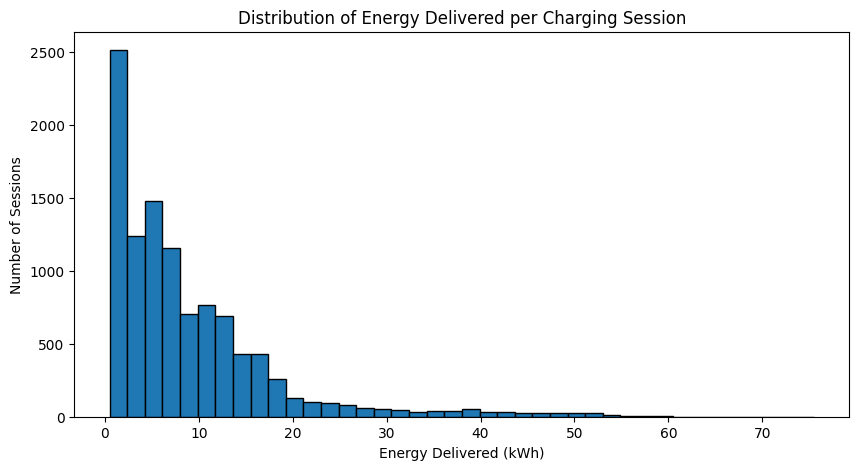

In [3]:
plt.figure(figsize=(10, 5))

plt.hist(df["kWhDelivered"], bins=40, edgecolor="black")

plt.title("Distribution of Energy Delivered per Charging Session")
plt.xlabel("Energy Delivered (kWh)")
plt.ylabel("Number of Sessions")

plt.show()

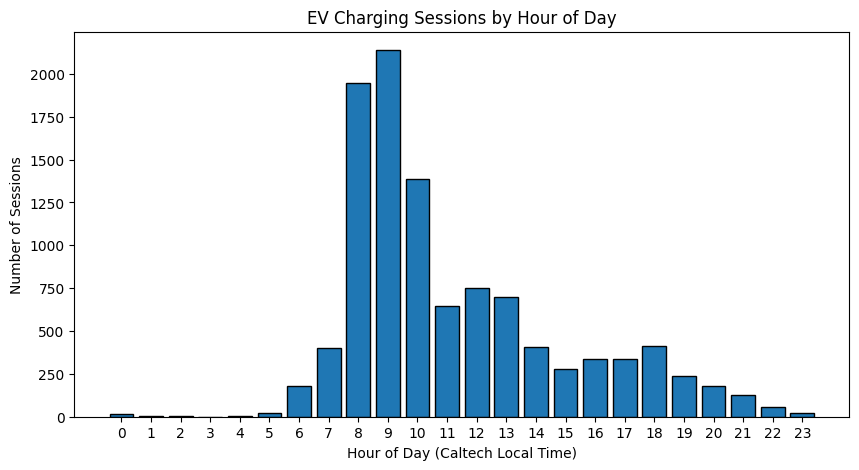

In [4]:
hourly_sessions = (
    df.groupby("hour")
      .size()
      .reindex(range(24), fill_value=0)
)

plt.figure(figsize=(10, 5))

plt.bar(hourly_sessions.index, hourly_sessions.values, edgecolor="black")

plt.title("EV Charging Sessions by Hour of Day")
plt.xlabel("Hour of Day (Caltech Local Time)")
plt.ylabel("Number of Sessions")
plt.xticks(range(24))

plt.show()

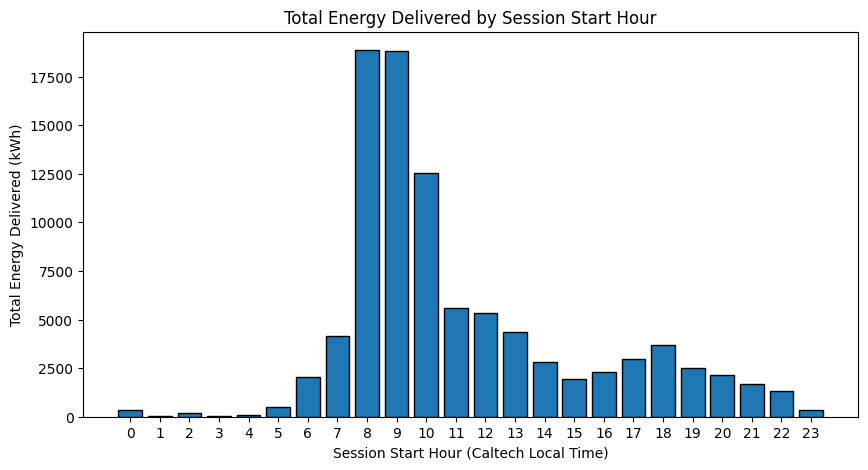

In [5]:
energy_by_start_hour = (
    df.groupby("hour")["kWhDelivered"]
      .sum()
      .reindex(range(24), fill_value=0)
)

plt.figure(figsize=(10, 5))

plt.bar(
    energy_by_start_hour.index,
    energy_by_start_hour.values,
    edgecolor="black"
)

plt.title("Total Energy Delivered by Session Start Hour")
plt.xlabel("Session Start Hour (Caltech Local Time)")
plt.ylabel("Total Energy Delivered (kWh)")
plt.xticks(range(24))

plt.show()

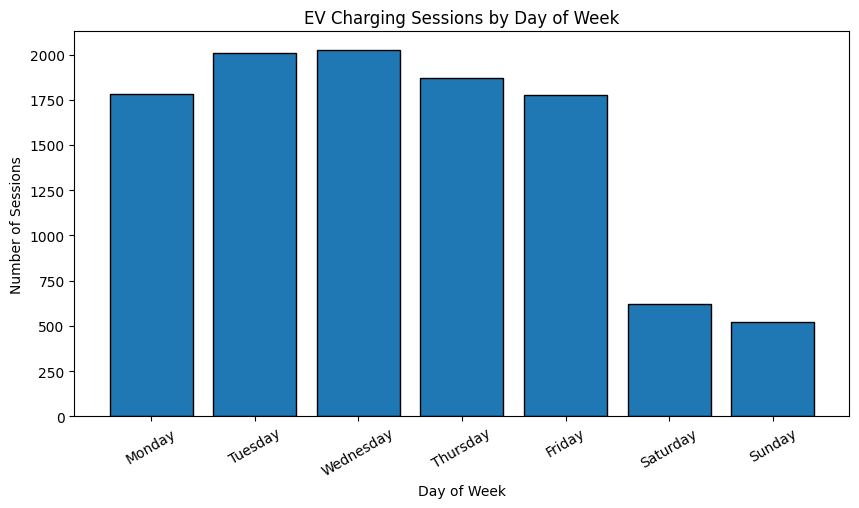

In [6]:
day_order = [
    "Monday", "Tuesday", "Wednesday",
    "Thursday", "Friday", "Saturday", "Sunday"
]

sessions_by_day = (
    df.groupby("day_name")
      .size()
      .reindex(day_order)
)

plt.figure(figsize=(10, 5))

plt.bar(
    sessions_by_day.index,
    sessions_by_day.values,
    edgecolor="black"
)

plt.title("EV Charging Sessions by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Number of Sessions")
plt.xticks(rotation=30)

plt.show()

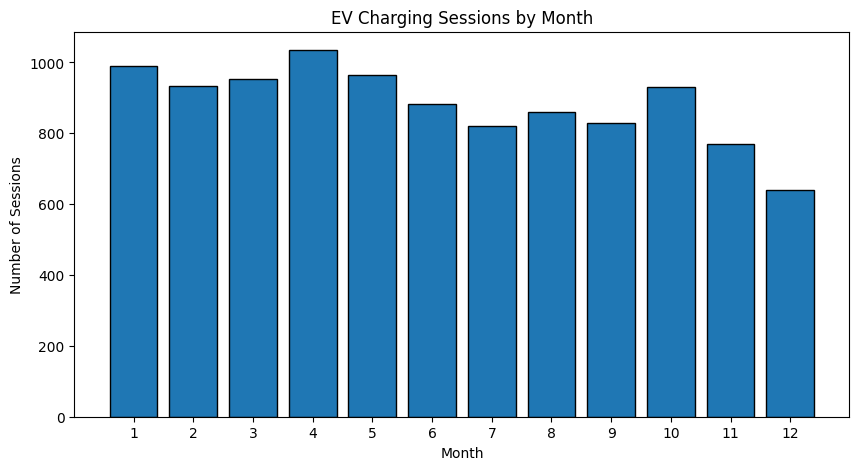

In [7]:
sessions_by_month = (
    df.groupby("month")
      .size()
      .reindex(range(1, 13), fill_value=0)
)

plt.figure(figsize=(10, 5))

plt.bar(
    sessions_by_month.index,
    sessions_by_month.values,
    edgecolor="black"
)

plt.title("EV Charging Sessions by Month")
plt.xlabel("Month")
plt.ylabel("Number of Sessions")
plt.xticks(range(1, 13))

plt.show()

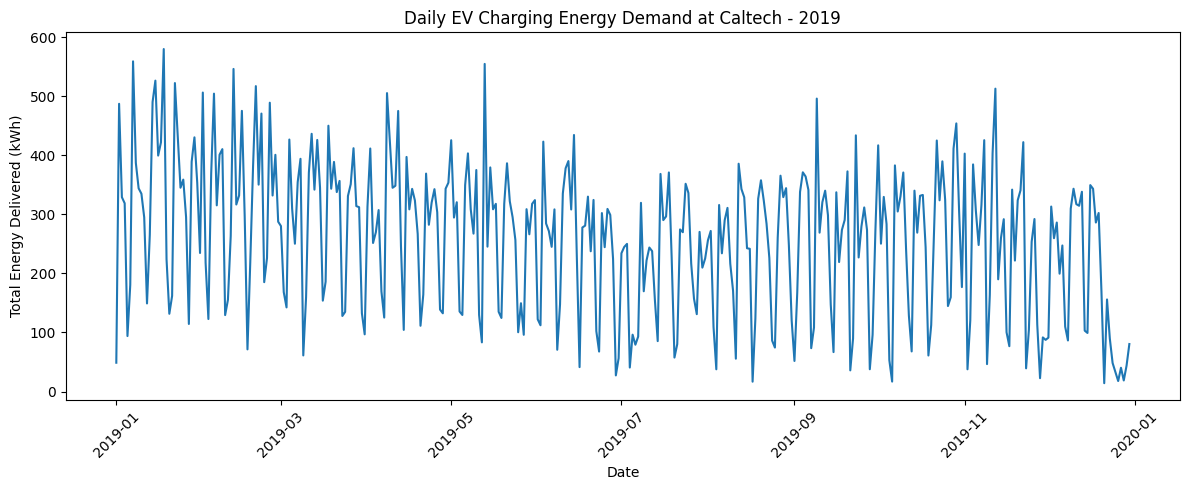

In [8]:
daily_energy = (
    df.groupby("date")["kWhDelivered"]
      .sum()
)

daily_energy.index = pd.to_datetime(daily_energy.index)

plt.figure(figsize=(12, 5))

plt.plot(daily_energy.index, daily_energy.values)

plt.title("Daily EV Charging Energy Demand at Caltech - 2019")
plt.xlabel("Date")
plt.ylabel("Total Energy Delivered (kWh)")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

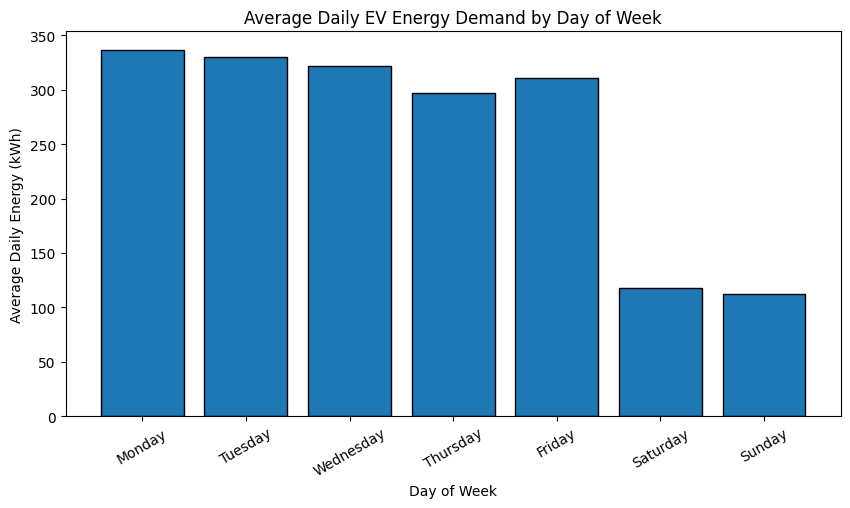

day_name
Monday       336.64
Tuesday      330.26
Wednesday    321.58
Thursday     296.99
Friday       310.36
Saturday     118.29
Sunday       111.96
Name: total_energy_kWh, dtype: float64


In [9]:
daily = (
    df.groupby("date")
      .agg(
          total_energy_kWh=("kWhDelivered", "sum"),
          sessions=("sessionID", "count")
      )
      .reset_index()
)

daily["date"] = pd.to_datetime(daily["date"])
daily["day_name"] = daily["date"].dt.day_name()

day_order = [
    "Monday", "Tuesday", "Wednesday",
    "Thursday", "Friday", "Saturday", "Sunday"
]

avg_daily_energy = (
    daily.groupby("day_name")["total_energy_kWh"]
         .mean()
         .reindex(day_order)
)

plt.figure(figsize=(10, 5))
plt.bar(avg_daily_energy.index, avg_daily_energy.values, edgecolor="black")

plt.title("Average Daily EV Energy Demand by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Average Daily Energy (kWh)")
plt.xticks(rotation=30)

plt.show()

print(avg_daily_energy.round(2))

In [10]:
station_usage = (
    df.groupby("stationID")
      .agg(
          sessions=("sessionID", "count"),
          total_energy_kWh=("kWhDelivered", "sum"),
          avg_energy_kWh=("kWhDelivered", "mean")
      )
      .sort_values("sessions", ascending=False)
)

print("Number of stations:", len(station_usage))
station_usage.head(10)

Number of stations: 54


,sessions,total_energy_kWh,avg_energy_kWh
stationID,,,
2-39-139-28,650,6144.433495,9.452975
2-39-131-30,531,4792.944000,9.026260
2-39-89-25,451,2955.056927,6.552233
2-39-129-17,371,3117.165000,8.402062
2-39-123-23,356,2531.763523,7.111695
2-39-91-437,339,2715.471341,8.010240
2-39-95-27,329,3002.765000,9.126945
2-39-79-377,324,3417.625886,10.548228
2-39-79-379,310,2729.068813,8.803448


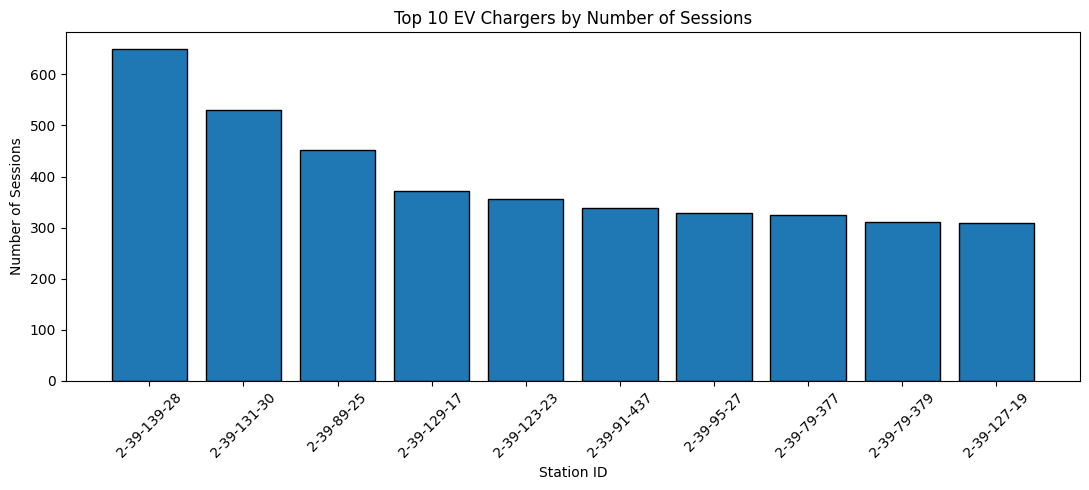

In [11]:
top10_stations = station_usage.head(10)

plt.figure(figsize=(11, 5))

plt.bar(
    top10_stations.index,
    top10_stations["sessions"],
    edgecolor="black"
)

plt.title("Top 10 EV Chargers by Number of Sessions")
plt.xlabel("Station ID")
plt.ylabel("Number of Sessions")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [12]:
duration_data = df.dropna(subset=["charging_hours"]).copy()

# Keep only physically interpretable duration records for this comparison
duration_data = duration_data[
    (duration_data["charging_hours"] >= 0) &
    (duration_data["charging_hours"] <= duration_data["connected_hours"])
]

print("Sessions used:", len(duration_data))

print(
    duration_data[
        ["connected_hours", "charging_hours"]
    ].describe().round(2)
)

print(
    "\nAverage idle plugged-in time:",
    round(
        (duration_data["connected_hours"] -
         duration_data["charging_hours"]).mean(),
        2
    ),
    "hours"
)

Sessions used: 9817
       connected_hours  charging_hours
count          9817.00         9817.00
mean              6.11            2.82
std               5.72            3.74
min               0.09            0.00
25%               2.41            1.18
50%               5.91            1.96
75%               8.63            3.62
max             214.32          200.02

Average idle plugged-in time: 3.28 hours
